In [1]:
import os 
os.chdir("D:/Myprojects/frauddetection")


In [5]:
#Importing required libraries 
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler ,OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import joblib

In [6]:

# Data Collection And A small inspection about  data set
trans_df  = pd.read_csv("transactions.csv")
print(trans_df.info())
print(trans_df.head())
print(trans_df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197586 entries, 0 to 197585
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   step              197586 non-null  int64  
 1   customer          197586 non-null  object 
 2   age               197586 non-null  object 
 3   gender            197586 non-null  object 
 4   zipcodeOri        197586 non-null  object 
 5   merchant          197586 non-null  object 
 6   zipMerchant       197586 non-null  object 
 7   category          197586 non-null  object 
 8   amount            197586 non-null  float64
 9   fraud             197586 non-null  int64  
 10  transaction_time  197586 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 16.6+ MB
None
   step       customer  age gender zipcodeOri       merchant zipMerchant  \
0     0  'C1093826151'  22'    'M'    '28007'   'M348934600'     '28007'   
1     0   'C352968107'  24'    'M'    '28007'

C:\Users\chara\AppData\Local\Temp\ipykernel_27980\3477376705.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  trans_df  = pd.read_csv("transactions.csv")


In [7]:

#Data preprocessing

#Handling null values 
print(trans_df.isnull().sum())
trans_df['age'].fillna(trans_df['age'].mode,inplace=True)
trans_df['transaction_time'].fillna(trans_df['transaction_time'].mode,inplace=True)

#changing some columns data types 
trans_df['age']  = trans_df['age'].str.extract('(\d+)')
trans_df['age']  = pd.to_numeric(trans_df['age'],errors='coerce')
trans_df['amount'] = pd.to_numeric(trans_df['amount'],errors='coerce')
trans_df['transaction_time'] = pd.to_numeric(trans_df['transaction_time'],errors='coerce')
trans_df['zipcodeOri']  = trans_df['zipcodeOri'].str.extract('(\d+)')
trans_df['zipcodeOri'] = pd.to_numeric(trans_df['zipcodeOri'],errors = 'coerce')

print(trans_df.info())

step                0
customer            0
age                 0
gender              0
zipcodeOri          0
merchant            0
zipMerchant         0
category            0
amount              0
fraud               0
transaction_time    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197586 entries, 0 to 197585
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   step              197586 non-null  int64  
 1   customer          197586 non-null  object 
 2   age               197244 non-null  float64
 3   gender            197586 non-null  object 
 4   zipcodeOri        197586 non-null  int64  
 5   merchant          197586 non-null  object 
 6   zipMerchant       197586 non-null  object 
 7   category          197586 non-null  object 
 8   amount            197586 non-null  float64
 9   fraud             197586 non-null  int64  
 10  transaction_time  197585 non-null  float64
dtypes: fl

In [8]:


#Feature Engineering
#Features And Targets 
X  =  trans_df [['amount','age','merchant','zipcodeOri','transaction_time']]
y  = trans_df['fraud']

#Categorical Data Encoding
#define columns
num = ['age','amount','transaction_time']
cat  = ['merchant','zipcodeOri']

#Splitting Data
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2,random_state=42)

#Feature Scaling And Encoding
preprocessor  = ColumnTransformer([('num',StandardScaler(),num),
            ('cat',OneHotEncoder(handle_unknown='ignore'),cat)
            ])

#Model Selection
xgb_model =XGBClassifier(scale_pos_weight = 72,
                                    n_estimators=100,
                                    max_depth=10,
                                    learning_rate=0.10,
                                    random_state=42)
#pipeline building
pipeline  = Pipeline(steps = [
    ('preprocessor',preprocessor),
    ('model',xgb_model)
])

#training
pipeline.fit(X_train,y_train)

#prediction 
result  = pipeline.predict(X_test)

#Model Evaluation
print("accuracy_score",accuracy_score(y_test,result))
print("confusion_matrix",confusion_matrix(y_test,result))
print("classification_report",classification_report(y_test,result))
print(trans_df['fraud'].value_counts())

#saving model
joblib.dump(pipeline,"fraud_model.pkl")

accuracy_score 0.9744926362670175
confusion_matrix [[38035   977]
 [   31   475]]
classification_report               precision    recall  f1-score   support

           0       1.00      0.97      0.99     39012
           1       0.33      0.94      0.49       506

    accuracy                           0.97     39518
   macro avg       0.66      0.96      0.74     39518
weighted avg       0.99      0.97      0.98     39518

fraud
0    194860
1      2726
Name: count, dtype: int64


['fraud_model.pkl']

In [9]:

#feature importances 
importance  = pipeline.named_steps['model'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

for i in zip(feature_names,importance):
    print(i)

('num__age', np.float32(0.001218538))
('num__amount', np.float32(0.13130327))
('num__transaction_time', np.float32(0.0011702385))
("cat__merchant_'M1053599405'", np.float32(0.017352093))
("cat__merchant_'M117188757'", np.float32(0.0))
("cat__merchant_'M1198415165'", np.float32(0.026055302))
("cat__merchant_'M1294758098'", np.float32(0.002549874))
("cat__merchant_'M1313686961'", np.float32(0.0036290889))
("cat__merchant_'M1352454843'", np.float32(0.0040172026))
("cat__merchant_'M1353266412'", np.float32(0.0045396658))
("cat__merchant_'M1400236507'", np.float32(0.0038314436))
("cat__merchant_'M1416436880'", np.float32(0.0024369585))
("cat__merchant_'M151143676'", np.float32(0.006896483))
("cat__merchant_'M1535107174'", np.float32(0.0115077095))
("cat__merchant_'M1600850729'", np.float32(0.011640052))
("cat__merchant_'M1649169323'", np.float32(0.0023400867))
("cat__merchant_'M1726401631'", np.float32(0.0))
("cat__merchant_'M17379832'", np.float32(0.028064387))
("cat__merchant_'M1741626453

In [12]:

#cross validation 
validate  = cross_val_score(pipeline,X_train,y_train,cv = 5)
print("Accuracy:",np.mean(validate),validate)

Accuracy: 0.9767188780748185 [0.97478965 0.97716202 0.97858544 0.97599089 0.9770664 ]


[]

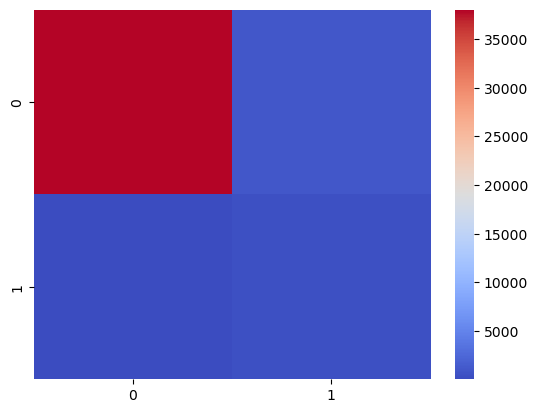

In [13]:
#conmfusion matrix visulization 
sns.heatmap(confusion_matrix(y_test,result),cmap='coolwarm')
plt.plot()

                step            age  zipcodeOri         amount          fraud  \
count  197586.000000  197244.000000    197586.0  197586.000000  197586.000000   
mean       35.032877      24.493891     28007.0      39.149616       0.013797   
std        19.471889       5.975314         0.0     124.926533       0.116646   
min         0.000000       0.000000     28007.0       0.000000       0.000000   
25%        19.000000      22.000000     28007.0      13.750000       0.000000   
50%        36.000000      24.000000     28007.0      26.950000       0.000000   
75%        52.000000      28.000000     28007.0      42.750000       0.000000   
max        68.000000      35.000000     28007.0    7665.560000       1.000000   

       transaction_time  
count     197585.000000  
mean          11.365114  
std            6.913302  
min            0.000000  
25%            5.000000  
50%           11.000000  
75%           17.000000  
max           23.000000  


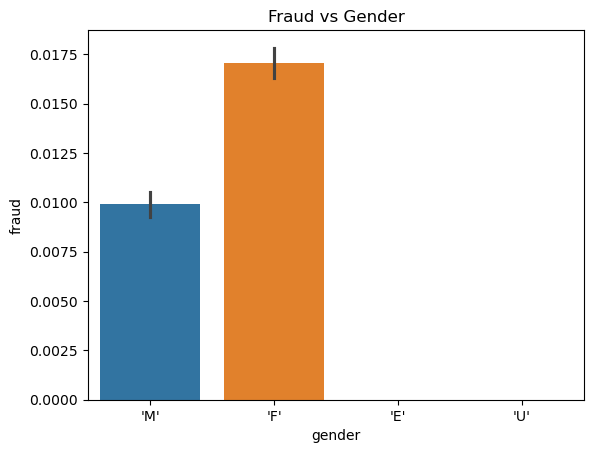

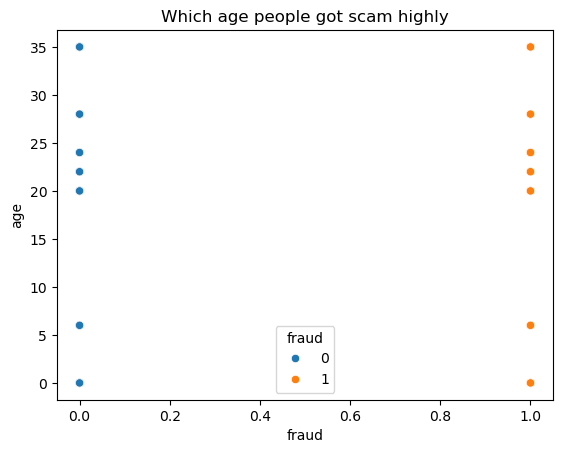

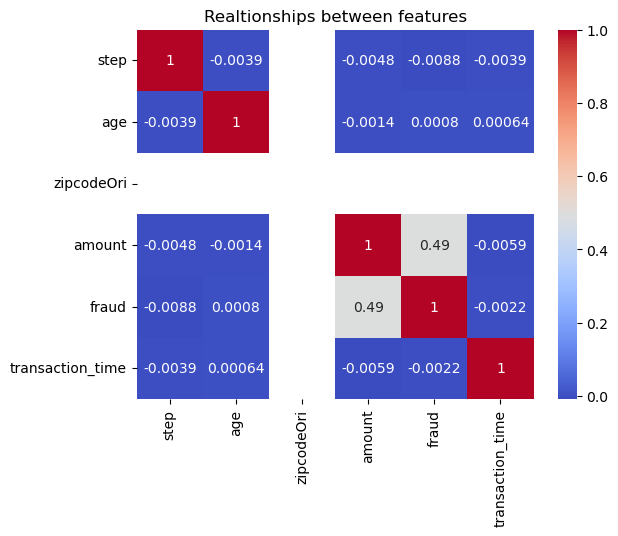

In [16]:

# Exploratory data analysis
print(trans_df.describe())
#in which gender the most fraud happening
sns.barplot(x='gender',y='fraud',data = trans_df,hue='gender')
plt.title("Fraud vs Gender")
plt.show()

#In which age the most fraud happening
sns.scatterplot(x ='fraud',y='age',data = trans_df,hue='fraud')
plt.title("Which age people got scam highly")
plt.show()

#correlations 
corr = trans_df.corr(numeric_only=True)
sns.heatmap(corr,cmap='coolwarm',annot=True)
plt.title("Realtionships between features")
plt.show()
